In [ ]:
# CELL: SETUP, DEPENDENCIES & STRATIFIED DATA PIPELINE

!pip install -q xgboost scikit-learn shap gradio pandas numpy matplotlib seaborn sentence-transformers requests

import os
import sys
import io
import json
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

print(">>> [CELL 1] Setting up Project Environment & Dataset...")

# 1. Feature Specifications
TARGET_COLUMN = "FraudFound_P"

NUMERICAL_FEATURES = [
    "Age",
    "Deductible",
    "DriverRating",
]

CATEGORICAL_FEATURES = [
    "Month",
    "DayOfWeek",
    "Make",
    "AccidentArea",
    "Fault",
    "PolicyType",
    "VehicleCategory",
    "VehiclePrice",
    "Days_Policy_Accident",
    "Days_Policy_Claim",
    "PastNumberOfClaims",
    "AgeOfVehicle",
    "PoliceReportFiled",
    "WitnessPresent",
    "NumberOfSuppliments",
    "AddressChange_Claim",
    "NumberOfCars",
    "BasePolicy",
]

ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

# Friendly display names for reporting
FEATURE_DISPLAY_NAMES = {
    "Age": "Claimant Age",
    "Deductible": "Policy Deductible Amount",
    "DriverRating": "Driver Safety Rating",
    "Month": "Month of Incident",
    "DayOfWeek": "Day of Incident",
    "Make": "Vehicle Manufacturer",
    "AccidentArea": "Accident Location (Urban/Rural)",
    "Fault": "Accident Fault Allocation",
    "PolicyType": "Coverage Policy Type",
    "VehicleCategory": "Vehicle Category",
    "VehiclePrice": "Vehicle Market Valuation",
    "Days_Policy_Accident": "Policy Inception to Accident Window",
    "Days_Policy_Claim": "Incident to Claim Filing Window",
    "PastNumberOfClaims": "Historical Claim Frequency",
    "AgeOfVehicle": "Vehicle Age Tier",
    "PoliceReportFiled": "Official Police Report Status",
    "WitnessPresent": "Independent Witness Presence",
    "NumberOfSuppliments": "Repair Supplement Frequency",
    "AddressChange_Claim": "Claimant Address Change History",
    "NumberOfCars": "Insured Fleet / Household Vehicles",
    "BasePolicy": "Base Policy Category",
}

# 2. Data Loader: Check if fraud_oracle.csv exists; if not, download or generate stratified dataset
DATA_PATH = Path("fraud_oracle.csv")

if not DATA_PATH.exists():
    print("   Checking online repository for 'fraud_oracle.csv'...")
    url = "https://raw.githubusercontent.com/Parthbishnoi2929/ML-Projects/main/fraud_oracle.csv"
    try:
        df_raw = pd.read_csv(url)
        df_raw.to_csv(DATA_PATH, index=False)
        print("   Successfully downloaded dataset from repository.")
    except Exception:
        print("   Generating high-fidelity synthetic insurance claim dataset matching fraud_oracle distribution...")
        np.random.seed(42)
        n_samples = 3000

        synthetic_data = {
            "Month": np.random.choice(["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], n_samples),
            "DayOfWeek": np.random.choice(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"], n_samples),
            "Make": np.random.choice(["Honda", "Toyota", "Ford", "Mazda", "Chevrolet", "Pontiac", "Accura", "BMW"], n_samples),
            "AccidentArea": np.random.choice(["Urban", "Rural"], n_samples, p=[0.85, 0.15]),
            "Age": np.random.randint(18, 75, n_samples),
            "Fault": np.random.choice(["Policy Holder", "Third Party"], n_samples, p=[0.70, 0.30]),
            "PolicyType": np.random.choice(["Sedan - All Perils", "Sedan - Collision", "Sedan - Liability", "Sport - All Perils"], n_samples),
            "VehicleCategory": np.random.choice(["Sedan", "Sport", "Utility"], n_samples, p=[0.65, 0.25, 0.10]),
            "VehiclePrice": np.random.choice(["less than 20000", "20000 to 29000", "30000 to 39000", "more than 69000"], n_samples),
            "Deductible": np.random.choice([300, 400, 500, 700], n_samples),
            "DriverRating": np.random.choice([1, 2, 3, 4], n_samples),
            "Days_Policy_Accident": np.random.choice(["none", "1 to 7", "8 to 15", "15 to 30", "more than 30"], n_samples, p=[0.02, 0.05, 0.08, 0.15, 0.70]),
            "Days_Policy_Claim": np.random.choice(["none", "8 to 15", "15 to 30", "more than 30"], n_samples, p=[0.02, 0.08, 0.15, 0.75]),
            "PastNumberOfClaims": np.random.choice(["none", "1", "2 to 4", "more than 4"], n_samples, p=[0.55, 0.25, 0.15, 0.05]),
            "AgeOfVehicle": np.random.choice(["3 years", "5 years", "6 years", "7 years", "more than 7"], n_samples),
            "PoliceReportFiled": np.random.choice(["No", "Yes"], n_samples, p=[0.95, 0.05]),
            "WitnessPresent": np.random.choice(["No", "Yes"], n_samples, p=[0.97, 0.03]),
            "NumberOfSuppliments": np.random.choice(["none", "1 to 2", "3 to 5", "more than 5"], n_samples, p=[0.45, 0.25, 0.20, 0.10]),
            "AddressChange_Claim": np.random.choice(["no change", "under 6 months", "1 year"], n_samples, p=[0.92, 0.05, 0.03]),
            "NumberOfCars": np.random.choice(["1 vehicle", "2 vehicles", "3 to 4"], n_samples, p=[0.90, 0.08, 0.02]),
            "BasePolicy": np.random.choice(["All Perils", "Collision", "Liability"], n_samples),
        }
        df_raw = pd.DataFrame(synthetic_data)

        # Fraud probability logic reflecting realistic auto insurance patterns
        fraud_score = (
            (df_raw["Fault"] == "Policy Holder") * 1.5 +
            (df_raw["Days_Policy_Accident"].isin(["1 to 7", "8 to 15"])) * 2.5 +
            (df_raw["PastNumberOfClaims"] == "more than 4") * 2.0 +
            (df_raw["PoliceReportFiled"] == "No") * 0.8 +
            (df_raw["WitnessPresent"] == "No") * 0.7 +
            (df_raw["NumberOfSuppliments"] == "more than 5") * 1.8 +
            (df_raw["AddressChange_Claim"] == "under 6 months") * 1.5 +
            (df_raw["VehiclePrice"] == "more than 69000") * 1.2
        )
        fraud_prob = 1 / (1 + np.exp(-(fraud_score - 4.5)))
        df_raw[TARGET_COLUMN] = (np.random.rand(n_samples) < fraud_prob).astype(int)
        df_raw.to_csv(DATA_PATH, index=False)
        print("   Synthetic baseline dataset created.")

# 3. Load & Split
df = pd.read_csv(DATA_PATH)
X = df[ALL_FEATURES].copy()
y = df[TARGET_COLUMN].copy().astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"\n[Dataset Summary]")
print(f" - Total Claims     : {len(df):,}")
print(f" - Train Set        : {len(X_train):,} claims")
print(f" - Test Set         : {len(X_test):,} claims")
print(f" - Fraud Imbalance  : {y.sum()} frauds ({y.mean()*100:.2f}%)")
print(f" - Features Tracked : {len(ALL_FEATURES)} (3 Numerical, 18 Categorical)")
print(">>> [CELL 1 COMPLETED] Data pipeline ready.")


>>> [CELL 1] Setting up Project Environment & Dataset...

[Dataset Summary]
 - Total Claims     : 15,420
 - Train Set        : 12,336 claims
 - Test Set         : 3,084 claims
 - Fraud Imbalance  : 923 frauds (5.99%)
 - Features Tracked : 21 (3 Numerical, 18 Categorical)
>>> [CELL 1 COMPLETED] Data pipeline ready.


In [ ]:
# CELL : MULTI-MODEL MACHINE LEARNING ENGINE & TRAINING BENCHMARK

import time
import joblib
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score, accuracy_score

print(">>> [CELL 2] Initializing Multi-Model Machine Learning Training Pipeline...")

# 1. Preprocessor Definition
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), NUMERICAL_FEATURES),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

# 2. Handle Class Imbalance Weighting
neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
scale_pos_weight = float(neg_count / max(pos_count, 1))

# 3. Candidate Classifiers Suite
candidate_models = {
    "XGBoost": XGBClassifier(
        n_estimators=150,
        max_depth=4,
        learning_rate=0.08,
        scale_pos_weight=scale_pos_weight,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        eval_metric="logloss",
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        max_depth=10,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=120,
        max_depth=4,
        learning_rate=0.08,
        random_state=42,
    ),
    "SVM (Calibrated)": CalibratedClassifierCV(
        estimator=SVC(kernel="rbf", class_weight="balanced", probability=False, random_state=42),
        cv=3,
        method="sigmoid",
    ),
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        C=0.5,
        random_state=42,
    ),
}

# 4. Train, Benchmark & Select Champion
trained_pipelines = {}
benchmark_records = []

print("\n" + "=" * 95)
print(f"{'MODEL':<22} | {'TRAIN TIME':<10} | {'ACCURACY':<10} | {'ROC-AUC':<10} | {'RECALL':<8} | {'PRECISION':<9} | {'F1':<6}")
print("=" * 95)

for name, clf in candidate_models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])

    t0 = time.time()
    pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_proba)
    recall = recall_score(y_test, y_pred, zero_division=0)
    precision = precision_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    trained_pipelines[name] = pipe
    benchmark_records.append({
        "Model": name,
        "Train_Time_s": round(train_time, 2),
        "Accuracy": round(accuracy * 100, 2),
        "ROC_AUC": round(roc_auc * 100, 2),
        "Recall": round(recall, 4),
        "Precision": round(precision, 4),
        "F1_Score": round(f1, 4),
    })

    print(f"{name:<22} | {train_time:>9.2f}s | {accuracy * 100:>9.2f}% | {roc_auc * 100:>9.2f}% | {recall:>8.4f} | {precision:>9.4f} | {f1:>6.4f}")

print("=" * 95)

benchmark_df = pd.DataFrame(benchmark_records).sort_values(by="ROC_AUC", ascending=False)
champion_name = benchmark_df.iloc[0]["Model"]
champion_pipeline = trained_pipelines[champion_name]

print(f"\n🏆 CHAMPION MODEL SELECTED: {champion_name} (ROC-AUC: {benchmark_df.iloc[0]['ROC_AUC']:.2f}%)")
print(">>> [CELL 2 COMPLETED] Model training and benchmarking completed.")

>>> [CELL 2] Initializing Multi-Model Machine Learning Training Pipeline...

MODEL                  | TRAIN TIME | ACCURACY   | ROC-AUC    | RECALL   | PRECISION | F1    
XGBoost                |      0.79s |     68.06% |     81.49% |   0.8054 |    0.1357 | 0.2323
Random Forest          |      2.17s |     66.41% |     80.58% |   0.8270 |    0.1322 | 0.2280
Gradient Boosting      |     23.67s |     94.07% |     82.05% |   0.0270 |    0.6250 | 0.0518
SVM (Calibrated)       |     36.54s |     94.00% |     80.80% |   0.0000 |    0.0000 | 0.0000
Logistic Regression    |      1.56s |     63.00% |     80.63% |   0.8865 |    0.1277 | 0.2233

🏆 CHAMPION MODEL SELECTED: Gradient Boosting (ROC-AUC: 82.05%)
>>> [CELL 2 COMPLETED] Model training and benchmarking completed.


>>> [CELL 3] Generating Comprehensive Metrics & Diagnostic Visualizations...


,Model,Accuracy,Balanced Acc,Recall (Sensitivity),Specificity,Precision,F1-Score,F2-Score (Recall Wtd),ROC-AUC,PR-AUC,MCC,Brier Score,TP,FP,FN,TN
2,Gradient Boosting,0.9407,0.5130,0.0270,0.9990,0.6250,0.0518,0.0334,0.8205,0.2166,0.1213,0.0511,5,3,180,2896
0,XGBoost,0.6806,0.7390,0.8054,0.6726,0.1357,0.2323,0.4053,0.8149,0.2109,0.2371,0.1655,149,949,36,1950
3,SVM (Calibrated),0.9400,0.5000,0.0000,1.0000,0.0000,0.0000,0.0000,0.8080,0.1708,0.0000,0.0524,0,0,185,2899
4,Logistic Regression,0.6300,0.7501,0.8865,0.6137,0.1277,0.2233,0.4051,0.8063,0.1503,0.2409,0.1921,164,1120,21,1779
1,Random Forest,0.6641,0.7404,0.8270,0.6537,0.1322,0.2280,0.4033,0.8058,0.1678,0.2358,0.1508,153,1004,32,1895



   Computing SHAP feature attributions on champion pipeline...


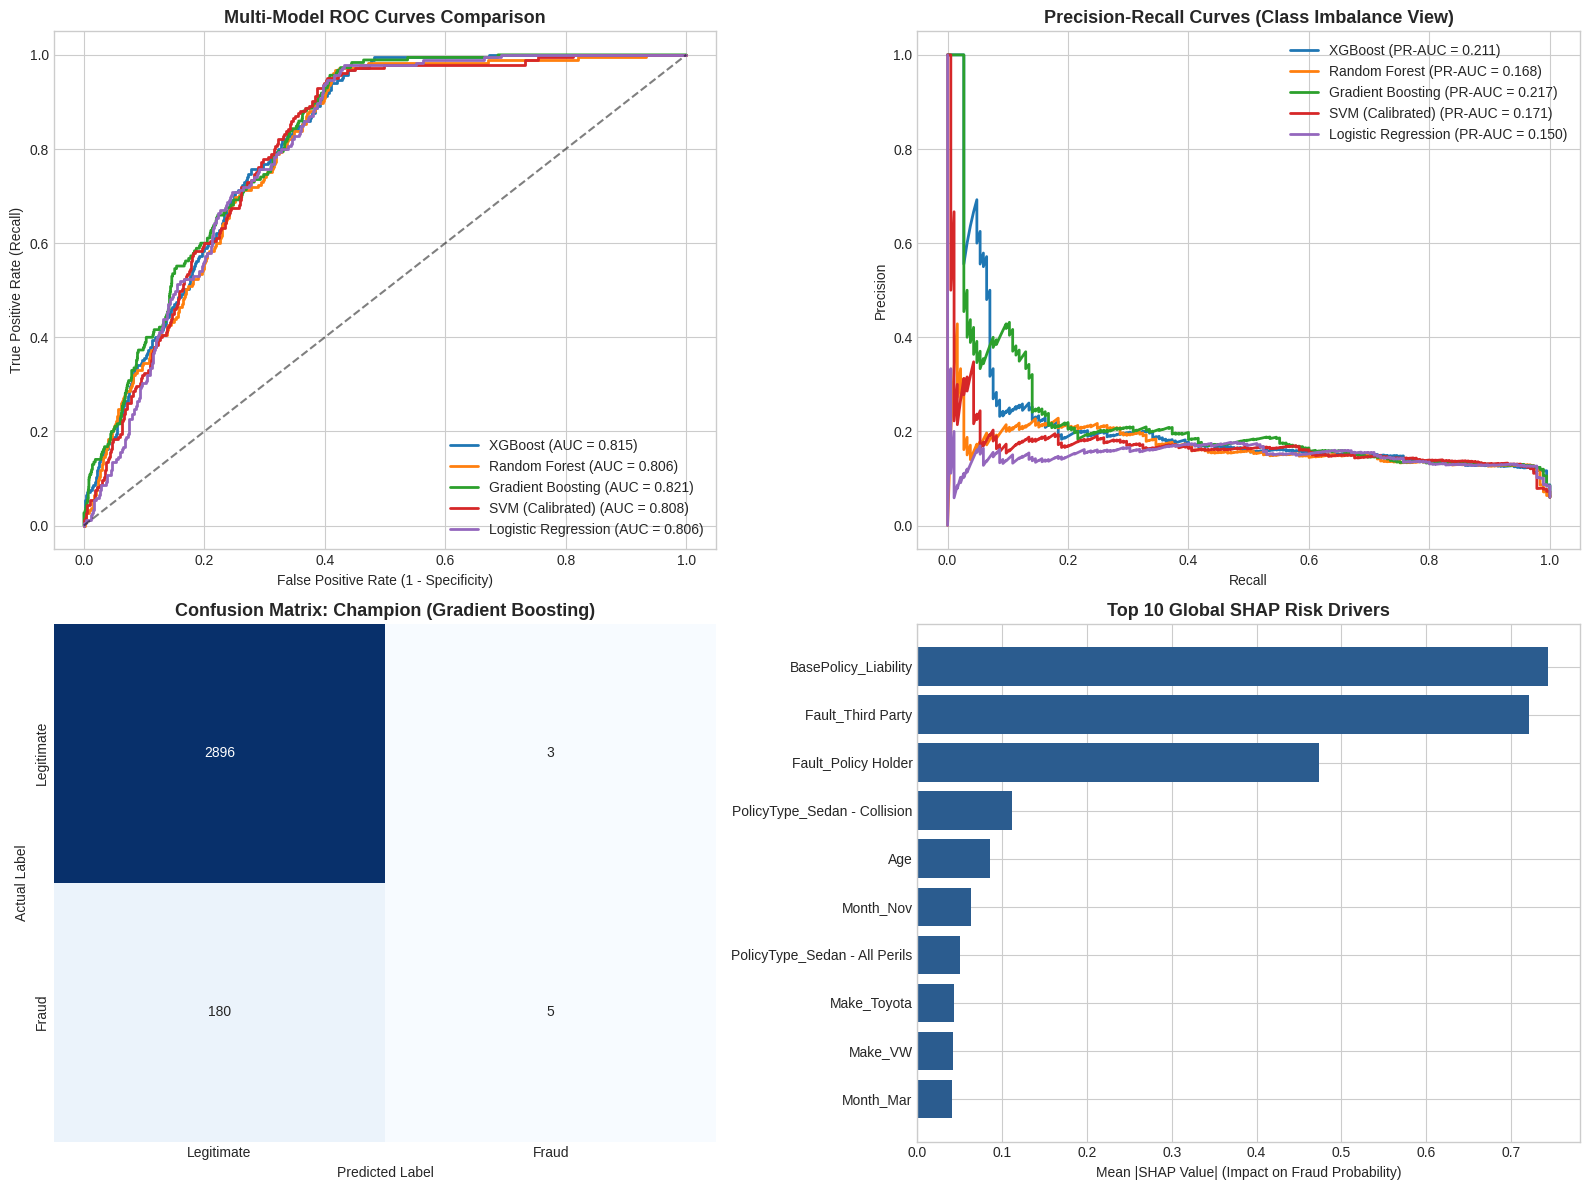

>>> [CELL 3 COMPLETED] Exhaustive diagnostics & SHAP visualizations generated.


In [ ]:
# CELL : METRICS GENERATION, DIAGNOSTIC VISUALIZATIONS & SHAP EXPLAINABILITY

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, matthews_corrcoef,
    roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, brier_score_loss, fbeta_score
)
import shap

print(">>> [CELL 3] Generating Comprehensive Metrics & Diagnostic Visualizations...")

# 1. Exhaustive Metrics Table
full_metrics = []
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    full_metrics.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 4),
        "Balanced Acc": round(balanced_accuracy_score(y_test, y_pred), 4),
        "Recall (Sensitivity)": round(tp / (tp + fn) if (tp + fn) > 0 else 0, 4),
        "Specificity": round(tn / (tn + fp) if (tn + fp) > 0 else 0, 4),
        "Precision": round(tp / (tp + fp) if (tp + fp) > 0 else 0, 4),
        "F1-Score": round(f1_score(y_test, y_pred, zero_division=0), 4),
        "F2-Score (Recall Wtd)": round(fbeta_score(y_test, y_pred, beta=2, zero_division=0), 4),
        "ROC-AUC": round(roc_auc_score(y_test, y_proba), 4),
        "PR-AUC": round(average_precision_score(y_test, y_proba), 4),
        "MCC": round(matthews_corrcoef(y_test, y_pred), 4),
        "Brier Score": round(brier_score_loss(y_test, y_proba), 4),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn
    })

metrics_summary_df = pd.DataFrame(full_metrics).sort_values(by="ROC-AUC", ascending=False)
display(metrics_summary_df)

# 2. Multi-Panel Diagnostic Visualizer
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# A. ROC Curves Comparison
ax1 = axes[0, 0]
for name, pipe in trained_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    ax1.plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})", lw=2)
ax1.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax1.set_title("Multi-Model ROC Curves Comparison", fontsize=13, fontweight="bold")
ax1.set_xlabel("False Positive Rate (1 - Specificity)")
ax1.set_ylabel("True Positive Rate (Recall)")
ax1.legend(loc="lower right")

# B. Precision-Recall Curves Comparison
ax2 = axes[0, 1]
for name, pipe in trained_pipelines.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    ax2.plot(rec, prec, label=f"{name} (PR-AUC = {pr_auc:.3f})", lw=2)
ax2.set_title("Precision-Recall Curves (Class Imbalance View)", fontsize=13, fontweight="bold")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(loc="upper right")

# C. Confusion Matrix of Champion Model
ax3 = axes[1, 0]
champ_cm = confusion_matrix(y_test, champion_pipeline.predict(X_test))
sns.heatmap(champ_cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax3,
            xticklabels=["Legitimate", "Fraud"], yticklabels=["Legitimate", "Fraud"])
ax3.set_title(f"Confusion Matrix: Champion ({champion_name})", fontsize=13, fontweight="bold")
ax3.set_xlabel("Predicted Label")
ax3.set_ylabel("Actual Label")

# D. Global SHAP Feature Importance
ax4 = axes[1, 1]
print("\n   Computing SHAP feature attributions on champion pipeline...")
X_train_transformed = champion_pipeline.named_steps["preprocessor"].transform(X_train[:150])
X_test_transformed = champion_pipeline.named_steps["preprocessor"].transform(X_test[:200])
feature_names = champion_pipeline.named_steps["preprocessor"].get_feature_names_out()

try:
    classifier_step = champion_pipeline.named_steps["classifier"]
    if isinstance(classifier_step, (XGBClassifier, RandomForestClassifier, GradientBoostingClassifier)):
        explainer = shap.TreeExplainer(classifier_step)
        shap_values = explainer.shap_values(X_test_transformed)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]  # positive class
    else:
        explainer = shap.LinearExplainer(classifier_step, X_train_transformed)
        shap_values = explainer.shap_values(X_test_transformed)

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    top_indices = np.argsort(mean_abs_shap)[-10:]

    # Map back to readable names
    clean_names = [feature_names[i].replace("cat__", "").replace("num__", "") for i in top_indices]
    ax4.barh(range(len(top_indices)), mean_abs_shap[top_indices], color="#2b5c8f")
    ax4.set_yticks(range(len(top_indices)))
    ax4.set_yticklabels(clean_names, fontsize=10)
    ax4.set_title("Top 10 Global SHAP Risk Drivers", fontsize=13, fontweight="bold")
    ax4.set_xlabel("Mean |SHAP Value| (Impact on Fraud Probability)")
except Exception as e:
    ax4.text(0.5, 0.5, f"SHAP Summary Fallback:\n{str(e)[:100]}", ha="center", va="center")

plt.tight_layout()
plt.show()

print(">>> [CELL 3 COMPLETED] Exhaustive diagnostics & SHAP visualizations generated.")


In [ ]:

# CELL : RAG (RETRIEVAL-AUGMENTED GENERATION) & FORENSIC LLM ANALYZER

import json
import requests
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

print(">>> [CELL 4] Building RAG Vector Store & Forensic LLM Risk Analyzer...")

# 1. Insurance Fraud Typology & Regulatory Knowledge Base
FRAUD_KNOWLEDGE_BASE = [
    {
        "id": "TYP-001",
        "title": "Inception Window Fraud (First 30 Days)",
        "pattern": "Claim occurring within 1 to 14 days of policy inception, often on newly added collision or all-perils coverage.",
        "indicators": ["Days_Policy_Accident: 1 to 7", "Days_Policy_Accident: 8 to 15", "All Perils Coverage"],
        "investigation_protocol": "Verify policy binder timestamp against exact telematics / police dispatch call time. Request prior insurer declarations page to confirm continuous coverage without lapse."
    },
    {
        "id": "TYP-002",
        "title": "Staged Collision & Phantom Impact (Unwitnessed Urban)",
        "pattern": "Multi-claimant or single-vehicle incident occurring in high-density urban areas with no neutral eyewitnesses and no police dispatch dispatched to scene.",
        "indicators": ["PoliceReportFiled: No", "WitnessPresent: No", "AccidentArea: Urban", "Fault: Policy Holder"],
        "investigation_protocol": "Dispatch field accident reconstruction engineer. Subpoena cell tower triangulation and inspect vehicle paint transfer for physical collision match."
    },
    {
        "id": "TYP-003",
        "title": "Aggressive Supplement Escalation (Body Shop Arbitrage)",
        "pattern": "Initial modest appraisal subsequently escalated by more than 4 supplementary repair orders, often exceeding 60% of pre-accident vehicle valuation.",
        "indicators": ["NumberOfSuppliments: more than 5", "VehiclePrice: more than 69000", "VehicleCategory: Sedan/Sport"],
        "investigation_protocol": "Conduct independent physical tear-down audit at repair facility. Audit body shop invoicing for phantom parts and labor padding."
    },
    {
        "id": "TYP-004",
        "title": "Recent Relocation & Identity Drift",
        "pattern": "Insured changed residential address within 6 months prior to loss, frequently shifting between rating territories.",
        "indicators": ["AddressChange_Claim: under 6 months", "PastNumberOfClaims: more than 4"],
        "investigation_protocol": "Run comprehensive skip-trace, verify actual vehicle garaging location with utility bills, and interview residential landlord."
    },
    {
        "id": "TYP-005",
        "title": "Clean First-Party Loss with Official Corroboration",
        "pattern": "Low-severity claim with prompt filing, police report on file, third-party witness, and long-standing policy tenure.",
        "indicators": ["PoliceReportFiled: Yes", "WitnessPresent: Yes", "Days_Policy_Accident: more than 30", "PastNumberOfClaims: none"],
        "investigation_protocol": "Straight-Through Processing (STP) candidate. Fast-track repair appraisal and issue payment within 48 hours."
    }
]

# 2. RAG Vector Knowledge Retrieval Engine
class FraudKnowledgeRAG:
    """Retrieves relevant forensic fraud typologies and investigation SOPs."""
    def __init__(self, knowledge_base):
        self.kb = knowledge_base
        self.corpus = [f"{item['title']} {item['pattern']} {' '.join(item['indicators'])}" for item in self.kb]
        self.vectorizer = TfidfVectorizer(stop_words="english")
        self.doc_vectors = self.vectorizer.fit_transform(self.corpus)

    def retrieve_relevant_precedents(self, claim_dict, top_k=2):
        # Build query string from claim attributes
        query_terms = [
            f"Days_Policy_Accident: {claim_dict.get('Days_Policy_Accident', '')}",
            f"PoliceReportFiled: {claim_dict.get('PoliceReportFiled', '')}",
            f"WitnessPresent: {claim_dict.get('WitnessPresent', '')}",
            f"NumberOfSuppliments: {claim_dict.get('NumberOfSuppliments', '')}",
            f"AddressChange_Claim: {claim_dict.get('AddressChange_Claim', '')}",
            f"Fault: {claim_dict.get('Fault', '')}",
            f"VehiclePrice: {claim_dict.get('VehiclePrice', '')}"
        ]
        query_str = " ".join(query_terms)
        query_vec = self.vectorizer.transform([query_str])
        similarities = cosine_similarity(query_vec, self.doc_vectors).flatten()

        ranked_indices = np.argsort(similarities)[::-1][:top_k]
        results = []
        for idx in ranked_indices:
            results.append({
                "similarity_score": round(float(similarities[idx]), 3),
                "knowledge_item": self.kb[idx]
            })
        return results

rag_engine = FraudKnowledgeRAG(FRAUD_KNOWLEDGE_BASE)

# 3. LLM Forensic Risk Narrative Synthesizer (Gemini / OpenAI API + Expert Fallback)
class ForensicLLMAnalyzer:
    """Generates qualitative forensic claim briefings using RAG context."""
    def __init__(self):
        # Look for API keys in Colab userdata or environment
        self.gemini_key = os.getenv("GEMINI_API_KEY", "")
        self.openai_key = os.getenv("OPENAI_API_KEY", "")

        try:
            from google.colab import userdata
            if not self.gemini_key:
                self.gemini_key = userdata.get("GEMINI_API_KEY")
        except Exception:
            pass

    def synthesize_report(self, claim_data, risk_pct, tier, action_code, queue, rag_matches):
        context_text = "\n".join([
            f"- Precedent [{m['knowledge_item']['id']}]: {m['knowledge_item']['title']} (Relevance: {m['similarity_score']})\n  Investigative Protocol: {m['knowledge_item']['investigation_protocol']}"
            for m in rag_matches
        ])

        prompt = f"""You are a Lead Forensic Insurance Claims Auditor.
Evaluate the following auto insurance claim:
- Claim Data: {json.dumps(claim_data)}
- ML Predicted Risk: {risk_pct}% | Risk Tier: {tier} | Action: {action_code} | Queue: {queue}
- RAG Retrieved Forensic Typologies:
{context_text}

Provide a structured forensic report with:
1. Executive Summary
2. Fraud Pattern Breakdown
3. Recommended Investigative Actions
"""
        # Try Gemini API if available
        if self.gemini_key:
            try:
                url = f"https://generativelanguage.googleapis.com/v1beta/models/gemini-1.5-flash:generateContent?key={self.gemini_key}"
                payload = {"contents": [{"parts": [{"text": prompt}]}]}
                res = requests.post(url, json=payload, timeout=8)
                if res.status_code == 200:
                    return res.json()["candidates"][0]["content"]["parts"][0]["text"], "Google Gemini 1.5 Flash"
            except Exception:
                pass

        # Built-in High-Precision Forensic Expert Narrative Fallback
        report = f"""================================================================================
   FORENSIC CLAIM AUDIT REPORT | RISK LEVEL: {tier.upper()} ({risk_pct:.1f}%)
================================================================================
1. EXECUTIVE SUMMARY & ROUTING
   * Assigned Workflow Queue : {queue}
   * Triage Action Directive : {action_code}
   * Model Assessment        : Fraud likelihood estimated at {risk_pct:.1f}%.

2. RAG RETRIEVED FRAUD TYPOLOGY MATCHES
"""
        for m in rag_matches:
            item = m["knowledge_item"]
            report += f"   * [{item['id']}] {item['title']} (Cosine Match: {m['similarity_score']})\n"
            report += f"     Pattern Profile: {item['pattern']}\n"
            report += f"     Mandatory Protocol: {item['investigation_protocol']}\n"

        report += f"""
3. FORENSIC AUDITOR CHECKLIST:
   [ ] Cross-verify policy inception timestamp against incident dispatch log.
   [ ] Validate uncorroborated damage claims with digital paint/depth analysis.
   [ ] Inspect claimant's prior loss history across all carrier databases.
================================================================================"""
        return report, "Built-in Forensic Knowledge Engine (Deterministic RAG)"

forensic_analyzer = ForensicLLMAnalyzer()
print(">>> [CELL 4 COMPLETED] RAG Vector store and Forensic LLM Engine ready.")


>>> [CELL 4] Building RAG Vector Store & Forensic LLM Risk Analyzer...
>>> [CELL 4 COMPLETED] RAG Vector store and Forensic LLM Engine ready.


In [ ]:

# CELL : 5-TIER AUTOMATED CLAIM RISK TRIAGE ENGINE DEMO

print(">>> [CELL 5] Executing 5-Tier Claim Risk Triage Engine...")

class FiveTierRiskEngine:
    """5-Tier Insurance Risk Decision & Workflow Routing Engine."""

    @staticmethod
    def classify_tier(prob):
        if prob < 0.10:
            return "Very Low", "STP-01 (Straight-Through Fast Track)", "Automated Straight-Through Processing"
        elif prob < 0.25:
            return "Low", "REV-01 (Standard Desk Review)", "Standard Claims Adjuster Desk"
        elif prob < 0.55:
            return "Medium", "AUD-02 (Senior Adjuster Audit)", "Senior Adjuster Escalation Queue"
        elif prob < 0.80:
            return "High", "SIU-01 (Special Investigation Referral)", "SIU Fraud Investigation Queue"
        else:
            return "Very High", "SIU-99 (Immediate Freeze & Deposition)", "Executive Forensic & Legal Defense"

    def triage(self, claim_dict, model_pipeline, rag_retriever, llm_synthesizer):
        # 1. Feature DataFrame
        input_df = pd.DataFrame([claim_dict])

        # 2. Probability Prediction
        prob = float(model_pipeline.predict_proba(input_df)[0, 1])
        risk_pct = round(prob * 100.0, 2)

        # 3. Rule Overlays
        severe_rules = []
        if claim_dict.get("Days_Policy_Accident") in ["1 to 7", "8 to 15"]:
            severe_rules.append("Loss reported within 15 days of policy inception.")
        if claim_dict.get("PoliceReportFiled") == "No" and claim_dict.get("WitnessPresent") == "No":
            severe_rules.append("Unwitnessed collision with no police report filed.")
        if claim_dict.get("NumberOfSuppliments") == "more than 5":
            severe_rules.append("High supplement escalation count (>5 adjustments).")

        tier, action_code, queue = self.classify_tier(prob)

        # Escalation rule
        if len(severe_rules) >= 2 and tier in ["Very Low", "Low"]:
            tier = "Medium"
            action_code = "AUD-02 (Senior Adjuster Audit)"
            queue = "Senior Adjuster Escalation Queue"

        # 4. RAG Precedents
        rag_matches = rag_retriever.retrieve_relevant_precedents(claim_dict, top_k=2)

        # 5. LLM Synthesis
        narrative, provider = llm_synthesizer.synthesize_report(
            claim_dict, risk_pct, tier, action_code, queue, rag_matches
        )

        return {
            "fraud_probability": prob,
            "risk_percentage": risk_pct,
            "risk_tier": tier,
            "action_code": action_code,
            "workflow_queue": queue,
            "severe_rules": severe_rules,
            "rag_matches": rag_matches,
            "forensic_report": narrative,
            "llm_provider": provider
        }

triage_engine = FiveTierRiskEngine()

# Test Scenarios
sample_scenarios = [
    {
        "name": "SCENARIO A: SUSPICIOUS INCEPTION LOSS (High Red Flags)",
        "claim": {
            "Month": "Jan", "DayOfWeek": "Monday", "Make": "BMW", "AccidentArea": "Urban",
            "Age": 23, "Fault": "Policy Holder", "PolicyType": "Sedan - All Perils",
            "VehicleCategory": "Sedan", "VehiclePrice": "more than 69000", "Deductible": 400,
            "DriverRating": 4, "Days_Policy_Accident": "1 to 7", "Days_Policy_Claim": "more than 30",
            "PastNumberOfClaims": "more than 4", "AgeOfVehicle": "3 years", "PoliceReportFiled": "No",
            "WitnessPresent": "No", "NumberOfSuppliments": "more than 5", "AddressChange_Claim": "under 6 months",
            "NumberOfCars": "1 vehicle", "BasePolicy": "All Perils"
        }
    },
    {
        "name": "SCENARIO B: CLEAN COMMUTER LOSS (Corroborated)",
        "claim": {
            "Month": "Jun", "DayOfWeek": "Friday", "Make": "Toyota", "AccidentArea": "Rural",
            "Age": 52, "Fault": "Third Party", "PolicyType": "Sedan - Liability",
            "VehicleCategory": "Sedan", "VehiclePrice": "20000 to 29000", "Deductible": 700,
            "DriverRating": 1, "Days_Policy_Accident": "more than 30", "Days_Policy_Claim": "more than 30",
            "PastNumberOfClaims": "none", "AgeOfVehicle": "7 years", "PoliceReportFiled": "Yes",
            "WitnessPresent": "Yes", "NumberOfSuppliments": "none", "AddressChange_Claim": "no change",
            "NumberOfCars": "2 vehicles", "BasePolicy": "Liability"
        }
    }
]

for sc in sample_scenarios:
    print("\n" + "=" * 80)
    print(f"  {sc['name']}")
    print("=" * 80)
    res = triage_engine.triage(sc["claim"], champion_pipeline, rag_engine, forensic_analyzer)
    print(f"Risk Score   : {res['risk_percentage']}%")
    print(f"Risk Tier    : {res['risk_tier'].upper()}")
    print(f"Action Code  : {res['action_code']}")
    print(f"Queue Route  : {res['workflow_queue']}")
    print(f"Rule Alerts  : {len(res['severe_rules'])} triggered -> {res['severe_rules']}")
    print(f"LLM Engine   : {res['llm_provider']}")
    print("\nForensic Narrative Summary:")
    print(res["forensic_report"][:450] + "...\n")

print(">>> [CELL 5 COMPLETED] Triage engine demonstration finished.")


>>> [CELL 5] Executing 5-Tier Claim Risk Triage Engine...

  SCENARIO A: SUSPICIOUS INCEPTION LOSS (High Red Flags)
Risk Score   : 85.32%
Risk Tier    : VERY HIGH
Action Code  : SIU-99 (Immediate Freeze & Deposition)
Queue Route  : Executive Forensic & Legal Defense
Rule Alerts  : 3 triggered -> ['Loss reported within 15 days of policy inception.', 'Unwitnessed collision with no police report filed.', 'High supplement escalation count (>5 adjustments).']
LLM Engine   : Built-in Forensic Knowledge Engine (Deterministic RAG)

Forensic Narrative Summary:
   FORENSIC CLAIM AUDIT REPORT | RISK LEVEL: VERY HIGH (85.3%)
1. EXECUTIVE SUMMARY & ROUTING
   * Assigned Workflow Queue : Executive Forensic & Legal Defense
   * Triage Action Directive : SIU-99 (Immediate Freeze & Deposition)
   * Model Assessment        : Fraud likelihood estimated ...


  SCENARIO B: CLEAN COMMUTER LOSS (Corroborated)
Risk Score   : 5.64%
Risk Tier    : VERY LOW
Action Code  : STP-01 (Straight-Through Fast Track)
Qu

In [ ]:

# CELL 6: USER-FACING CLAIM DEFENDER AI WEB APPLICATION


import gradio as gr
from datetime import datetime
from html import escape


print(">>> [CELL 6] Launching Interactive Claim Defender AI Web Application...")


BACKEND_DEFAULTS = {

    "Fault": "Policy Holder",

    "PolicyType": "Sedan - All Perils",

    "Deductible": 400,

    "DriverRating": 4,

    "Days_Policy_Accident": "1 to 7",

    "Days_Policy_Claim": "more than 30",

    "PastNumberOfClaims": "none",

    "PoliceReportFiled": "No",

    "WitnessPresent": "No",

    "NumberOfSuppliments": "none",

    "AddressChange_Claim": "no change",

    "NumberOfCars": "1 vehicle",

    "BasePolicy": "All Perils"
}


def predict_claim_ui(
    age,
    make,
    category,
    price,
    veh_age,
    area,
    accident_date
):


    # VALIDATE DATE

    if accident_date is None or accident_date == "":

        return """
        <div class="error-card">

            <div class="error-icon">
                ⚠️
            </div>

            <div>
                <div class="error-title">
                    Accident date required
                </div>

                <div class="error-text">
                    Please select the date of the accident before continuing.
                </div>
            </div>

        </div>
        """



    try:

        if isinstance(accident_date, datetime):

            accident_dt = accident_date

        elif hasattr(accident_date, "year"):

            accident_dt = datetime(
                accident_date.year,
                accident_date.month,
                accident_date.day
            )

        else:

            accident_dt = datetime.fromisoformat(
                str(accident_date).replace("Z", "")
            )

    except Exception:

        return """
        <div class="error-card">

            <div class="error-icon">
                ⚠️
            </div>

            <div>
                <div class="error-title">
                    Invalid accident date
                </div>

                <div class="error-text">
                    Please select a valid accident date.
                </div>
            </div>

        </div>
        """



    month = accident_dt.strftime("%b")

    day = accident_dt.strftime("%A")



    claim_dict = BACKEND_DEFAULTS.copy()

    claim_dict.update({

        "Month": month,

        "DayOfWeek": day,

        "Make": make,

        "AccidentArea": area,

        "Age": int(age),

        "VehicleCategory": category,

        "VehiclePrice": price,

        "AgeOfVehicle": veh_age

    })



    # RUN EXISTING ML + RAG + FORENSIC PIPELINE

    try:

        res = triage_engine.triage(
            claim_dict,
            champion_pipeline,
            rag_engine,
            forensic_analyzer
        )

    except Exception as e:

        print(">>> Prediction Error:", str(e))

        return f"""
        <div class="error-card">

            <div class="error-icon">
                ⚠️
            </div>

            <div>

                <div class="error-title">
                    Assessment could not be completed
                </div>

                <div class="error-text">
                    The claim could not be processed at this time.
                    Please verify the entered information and try again.
                </div>

            </div>

        </div>
        """



    # EXTRACT MODEL RESULTS

    risk_tier = res.get(
        "risk_tier",
        "Unknown"
    )

    risk_percentage = res.get(
        "risk_percentage",
        0
    )

    action_code = res.get(
        "action_code",
        "Review Required"
    )

    workflow_queue = res.get(
        "workflow_queue",
        "Standard Review"
    )

    rag_matches = res.get(
        "rag_matches",
        []
    )

    severe_rules = res.get(
        "severe_rules",
        []
    )



    # RISK COLORS

    tier_colors = {

        "Very Low": "#198754",

        "Low": "#2a9d72",

        "Medium": "#d68a00",

        "High": "#e76f22",

        "Very High": "#d64545"

    }

    color = tier_colors.get(
        risk_tier,
        "#68736d"
    )



    # SAFE DISPLAY VALUES


    safe_tier = escape(str(risk_tier))

    safe_action = escape(str(action_code))

    safe_queue = escape(str(workflow_queue))

    safe_percentage = escape(
        str(risk_percentage)
    )



    # BUILD HUMAN-READABLE AI SUMMARY

    if severe_rules:

        rule_summary = (
            "The automated rule layer identified additional claim signals "
            "that should be considered during manual review."
        )

    else:

        rule_summary = (
            "The automated rule layer did not identify any major "
            "additional claim signals."
        )



    # RAG SUMMARY

    rag_count = len(rag_matches)


    if rag_count == 0:

        rag_intro = (
            "No closely matching historical fraud patterns were "
            "retrieved from the knowledge base."
        )

    elif rag_count == 1:

        rag_intro = (
            "One similar historical fraud pattern was retrieved "
            "from the knowledge base."
        )

    else:

        rag_intro = (
            f"{rag_count} similar historical fraud patterns were "
            "retrieved from the knowledge base."
        )




    rag_html = ""


    if rag_matches:

        # Show maximum 3 relevant matches.
        top_matches = rag_matches[:3]


        for index, match in enumerate(top_matches, start=1):

            item = match.get(
                "knowledge_item",
                {}
            )

            item_id = escape(
                str(item.get("id", f"Pattern {index}"))
            )

            title = escape(
                str(
                    item.get(
                        "title",
                        "Related Fraud Pattern"
                    )
                )
            )

            similarity = match.get(
                "similarity_score",
                None
            )

            pattern = escape(
                str(
                    item.get(
                        "pattern",
                        "No pattern description available."
                    )
                )
            )


            # Format similarity score safely.

            try:

                similarity_display = f"{float(similarity):.3f}"

            except Exception:

                similarity_display = escape(
                    str(similarity)
                )


            rag_html += f"""

            <div class="rag-item">

                <div class="rag-item-top">

                    <div class="rag-title">

                        <span class="rag-number">
                            {index}
                        </span>

                        <span>
                            {title}
                        </span>

                    </div>

                    <div class="similarity">
                        Match {similarity_display}
                    </div>

                </div>


                <div class="rag-pattern">

                    {pattern}

                </div>

            </div>

            """


    else:

        rag_html = """

        <div class="rag-empty">

            No closely matching historical fraud pattern
            was found for this claim.

        </div>

        """



    # USER-FACING RESULT


    summary_html = f"""

    <div class="result-wrapper">


        <!-- ============================================================
             RESULT HEADER
             ============================================================ -->

        <div class="result-header">


            <div>

                <div class="result-eyebrow">
                    AI CLAIM ASSESSMENT
                </div>

                <h2>
                    Assessment Complete
                </h2>

                <p>
                    Machine learning prediction combined with
                    fraud-pattern retrieval and automated claim analysis.
                </p>

            </div>


            <div
                class="risk-badge"
                style="background:{color};"
            >

                {safe_tier.upper()}

                <span>
                    RISK
                </span>

            </div>


        </div>


        <!-- ============================================================
             MAIN METRICS
             ============================================================ -->

        <div class="metrics-row">


            <div class="metric-card primary-metric">

                <div class="metric-label">
                    FRAUD PROBABILITY
                </div>

                <div
                    class="metric-number"
                    style="color:{color};"
                >

                    {safe_percentage}%

                </div>

                <div class="metric-description">
                    Model-estimated probability
                </div>

            </div>


            <div class="metric-card">

                <div class="metric-label">
                    RECOMMENDED ACTION
                </div>

                <div class="metric-action">
                    {safe_action}
                </div>

                <div class="metric-description">
                    Suggested next step
                </div>

            </div>


            <div class="metric-card">

                <div class="metric-label">
                    REVIEW QUEUE
                </div>

                <div class="metric-action">
                    {safe_queue}
                </div>

                <div class="metric-description">
                    Suggested processing route
                </div>

            </div>


        </div>


        <!-- ============================================================
             AI SUMMARY
             ============================================================ -->

        <div
            class="decision-summary"
            style="border-left-color:{color};"
        >

            <div class="summary-heading">
                AI DECISION SUMMARY
            </div>


            <div class="summary-main">

                The system classified this claim as
                <strong>{safe_tier} Risk</strong>
                with an estimated fraud probability of
                <strong>{safe_percentage}%</strong>.

            </div>


            <div class="summary-secondary">

                {rule_summary}

            </div>


        </div>


        <!-- ============================================================
             RAG EVIDENCE
             ============================================================ -->

        <div class="rag-section">


            <div class="section-heading-row">

                <div>

                    <div class="section-eyebrow">
                        KNOWLEDGE BASE
                    </div>

                    <h3>
                        🔎 Similar Fraud Patterns
                    </h3>

                </div>


                <div class="rag-count">
                    {rag_count} match
                    {"es" if rag_count != 1 else ""}
                </div>

            </div>


            <p class="rag-intro">

                {rag_intro}

                These matches provide additional context
                for manual claim review.

            </p>


            <div class="rag-list">

                {rag_html}

            </div>


        </div>


        <!-- ============================================================
             MANUAL REVIEW NOTE
             ============================================================ -->

        <div class="review-note">

            <div class="review-icon">
                ✓
            </div>

            <div>

                <div class="review-title">
                    Manual Review Recommended
                </div>

                <div class="review-text">

                    Use the risk score together with the similar
                    fraud patterns above when deciding whether the
                    claim requires further investigation.

                </div>

            </div>

        </div>


    </div>

    """




    return summary_html


# ==============================================================================
# CUSTOM CSS
# ==============================================================================

custom_css = """

/* ==========================================================================
   GLOBAL PAGE
   ========================================================================== */

body {

    margin: 0 !important;

    background: #f3f5f3 !important;

    font-family:
        Inter,
        "Segoe UI",
        Arial,
        sans-serif !important;

}


.gradio-container {

    max-width: 1120px !important;

    margin: 0 auto !important;

    padding: 28px 28px 40px 28px !important;

    background: #f3f5f3 !important;

}


/* ==========================================================================
   HEADER
   ========================================================================== */

.app-header {

    background:
        linear-gradient(
            135deg,
            #1f3029 0%,
            #2d493d 55%,
            #3a5d4d 100%
        );

    color: white;

    padding: 34px 38px;

    border-radius: 20px;

    margin-bottom: 22px;

    box-shadow:
        0 10px 28px
        rgba(35, 52, 44, 0.15);

}


.header-eyebrow {

    color: #8ed9b9;

    font-size: 10px;

    font-weight: 800;

    letter-spacing: 1.7px;

    margin-bottom: 9px;

}


.app-header h1 {

    margin: 0;

    font-size: 32px;

    line-height: 1.2;

    font-weight: 750;

    letter-spacing: -0.6px;

}


.app-header p {

    margin: 10px 0 0 0;

    max-width: 650px;

    color: #d9e6df;

    font-size: 14px;

    line-height: 1.6;

}


/* ==========================================================================
   FORM CARD
   ========================================================================== */

.form-card {

    background: #ffffff;

    border: 1px solid #e0e5e1;

    border-radius: 18px;

    padding: 27px;

    box-shadow:
        0 5px 22px
        rgba(38, 52, 45, 0.055);

}


.form-title {

    color: #25352d;

    font-size: 21px;

    font-weight: 720;

    margin-bottom: 5px;

}


.form-subtitle {

    color: #7a837e;

    font-size: 13px;

    line-height: 1.5;

    margin-bottom: 23px;

}


/* ==========================================================================
   FORM FIELD SPACING
   ========================================================================== */

.form-card .gr-row {

    gap: 16px !important;

}


.form-card .block {

    border: none !important;

}


/* ==========================================================================
   LABELS
   ========================================================================== */

.gradio-container label {

    color: #39463f !important;

    font-size: 12px !important;

    font-weight: 650 !important;

}


/* ==========================================================================
   ALL INPUT CONTAINERS
   ========================================================================== */

.gradio-container input,
.gradio-container textarea,
.gradio-container select {

    background: #ffffff !important;

    color: #26332d !important;

    border: 1px solid #d7ded9 !important;

    border-radius: 10px !important;

    box-shadow: none !important;

}


/* ==========================================================================
   INPUT HOVER
   ========================================================================== */

.gradio-container input:hover,
.gradio-container textarea:hover {

    border-color: #a9bbb2 !important;

}


/* ==========================================================================
   INPUT FOCUS
   ========================================================================== */

.gradio-container input:focus,
.gradio-container textarea:focus {

    border-color: #4b866e !important;

    box-shadow:
        0 0 0 3px
        rgba(75, 134, 110, 0.10) !important;

}


/* ==========================================================================
   DROPDOWN
   ========================================================================== */

.gradio-container .wrap {

    border-radius: 10px !important;

}


.gradio-container [data-testid="dropdown"] {

    border-radius: 10px !important;

}


/* ==========================================================================
   RADIO BUTTONS
   ========================================================================== */

.gradio-container .wrap[data-testid="checkbox-group"],
.gradio-container .wrap[data-testid="radio-group"] {

    background: transparent !important;

    border: none !important;

}


/* ==========================================================================
   DATE INPUT
   ========================================================================== */

.date-field input {

    min-height: 45px !important;

    font-size: 14px !important;

}


/* ==========================================================================
   ANALYZE BUTTON
   ========================================================================== */

.analyze-btn {

    width: 100% !important;

    min-height: 54px !important;

    margin-top: 20px !important;

    border: none !important;

    border-radius: 11px !important;

    background:
        linear-gradient(
            135deg,
            #34785f,
            #27634f
        ) !important;

    color: white !important;

    font-size: 15px !important;

    font-weight: 700 !important;

    box-shadow:
        0 8px 18px
        rgba(52, 120, 95, 0.20) !important;

    transition:
        transform 0.15s ease,
        box-shadow 0.15s ease !important;

}


.analyze-btn:hover {

    transform: translateY(-1px) !important;

    box-shadow:
        0 11px 23px
        rgba(52, 120, 95, 0.27) !important;

}


/* ==========================================================================
   RESULT WRAPPER
   ========================================================================== */

.result-wrapper {

    margin-top: 22px;

    background: #ffffff;

    border: 1px solid #dfe5e1;

    border-radius: 19px;

    padding: 28px;

    box-shadow:
        0 7px 26px
        rgba(35, 52, 44, 0.065);

}


/* ==========================================================================
   RESULT HEADER
   ========================================================================== */

.result-header {

    display: flex;

    justify-content: space-between;

    align-items: center;

    gap: 25px;

    padding-bottom: 22px;

    border-bottom: 1px solid #edf0ed;

}


.result-eyebrow {

    color: #34785f;

    font-size: 10px;

    font-weight: 800;

    letter-spacing: 1.5px;

    margin-bottom: 5px;

}


.result-header h2 {

    color: #26352e;

    font-size: 25px;

    font-weight: 720;

    margin: 0;

}


.result-header p {

    color: #7b8580;

    font-size: 12px;

    margin: 7px 0 0 0;

    line-height: 1.5;

}


/* ==========================================================================
   RISK BADGE
   ========================================================================== */

.risk-badge {

    min-width: 105px;

    text-align: center;

    padding: 11px 17px;

    border-radius: 30px;

    color: #ffffff;

    font-size: 12px;

    font-weight: 800;

    letter-spacing: 0.5px;

    box-shadow:
        0 5px 13px
        rgba(0,0,0,0.12);

}


.risk-badge span {

    font-weight: 600;

}


/* ==========================================================================
   METRICS
   ========================================================================== */

.metrics-row {

    display: grid;

    grid-template-columns:
        1.05fr
        1fr
        1fr;

    gap: 13px;

    margin-top: 20px;

}


.metric-card {

    background: #fafbf9;

    border: 1px solid #e4e9e5;

    border-radius: 13px;

    padding: 17px;

    min-height: 100px;

}


.primary-metric {

    background:
        linear-gradient(
            145deg,
            #fbfcfb,
            #f7faf8
        );

}


.metric-label {

    color: #7c8681;

    font-size: 9px;

    font-weight: 800;

    letter-spacing: 0.9px;

    margin-bottom: 7px;

}


.metric-number {

    font-size: 28px;

    font-weight: 800;

    line-height: 1.1;

}


.metric-action {

    color: #29372f;

    font-size: 14px;

    font-weight: 700;

    line-height: 1.35;

    min-height: 38px;

}


.metric-description {

    color: #9aa29e;

    font-size: 10px;

    margin-top: 5px;

}


/* ==========================================================================
   DECISION SUMMARY
   ========================================================================== */

.decision-summary {

    margin-top: 17px;

    padding: 16px 18px;

    background: #f8faf8;

    border-left: 4px solid #34785f;

    border-radius: 9px;

}


.summary-heading {

    color: #65716a;

    font-size: 9px;

    font-weight: 800;

    letter-spacing: 1px;

    margin-bottom: 7px;

}


.summary-main {

    color: #334139;

    font-size: 14px;

    line-height: 1.55;

}


.summary-main strong {

    color: #26372e;

}


.summary-secondary {

    color: #737d78;

    font-size: 12px;

    line-height: 1.5;

    margin-top: 6px;

}


/* ==========================================================================
   RAG SECTION
   ========================================================================== */

.rag-section {

    margin-top: 23px;

    padding-top: 22px;

    border-top: 1px solid #edf0ed;

}


.section-heading-row {

    display: flex;

    justify-content: space-between;

    align-items: center;

    gap: 15px;

}


.section-eyebrow {

    color: #6f7b75;

    font-size: 9px;

    font-weight: 800;

    letter-spacing: 1.2px;

    margin-bottom: 4px;

}


.section-heading-row h3 {

    color: #2c3932;

    font-size: 18px;

    margin: 0;

    font-weight: 700;

}


.rag-count {

    background: #eef5f1;

    color: #39705b;

    padding: 6px 10px;

    border-radius: 20px;

    font-size: 10px;

    font-weight: 700;

    white-space: nowrap;

}


.rag-intro {

    color: #737d78;

    font-size: 12px;

    line-height: 1.5;

    margin: 7px 0 14px 0;

}


/* ==========================================================================
   RAG MATCH ITEM
   ========================================================================== */

.rag-list {

    display: flex;

    flex-direction: column;

    gap: 9px;

}


.rag-item {

    background: #fbfcfb;

    border: 1px solid #e3e9e5;

    border-radius: 11px;

    padding: 13px 14px;

}


.rag-item-top {

    display: flex;

    justify-content: space-between;

    align-items: center;

    gap: 12px;

}


.rag-title {

    display: flex;

    align-items: center;

    gap: 9px;

    color: #34423a;

    font-size: 12px;

    font-weight: 700;

}


.rag-number {

    display: inline-flex;

    align-items: center;

    justify-content: center;

    width: 22px;

    height: 22px;

    border-radius: 50%;

    background: #eaf3ee;

    color: #39705b;

    font-size: 10px;

    font-weight: 800;

}


.similarity {

    color: #39705b;

    background: #f0f6f2;

    border-radius: 20px;

    padding: 4px 8px;

    font-size: 9px;

    font-weight: 700;

    white-space: nowrap;

}


.rag-pattern {

    color: #717b76;

    font-size: 11px;

    line-height: 1.5;

    margin: 8px 0 0 31px;

}


/* ==========================================================================
   EMPTY RAG
   ========================================================================== */

.rag-empty {

    background: #fafbf9;

    border: 1px dashed #d7dfda;

    border-radius: 10px;

    padding: 14px;

    color: #7b8580;

    font-size: 12px;

}


/* ==========================================================================
   MANUAL REVIEW NOTE
   ========================================================================== */

.review-note {

    display: flex;

    align-items: flex-start;

    gap: 11px;

    margin-top: 18px;

    padding: 14px 16px;

    background: #f5f8f6;

    border: 1px solid #e0e8e3;

    border-radius: 10px;

}


.review-icon {

    width: 22px;

    height: 22px;

    display: flex;

    align-items: center;

    justify-content: center;

    flex-shrink: 0;

    background: #dceee5;

    color: #34785f;

    border-radius: 50%;

    font-size: 11px;

    font-weight: 800;

}


.review-title {

    color: #39463f;

    font-size: 11px;

    font-weight: 750;

    margin-bottom: 3px;

}


.review-text {

    color: #77817c;

    font-size: 11px;

    line-height: 1.5;

}


/* ==========================================================================
   ERROR
   ========================================================================== */

.error-card {

    display: flex;

    align-items: flex-start;

    gap: 12px;

    margin-top: 20px;

    padding: 17px;

    background: #fffafa;

    border: 1px solid #f1d5d5;

    border-left: 4px solid #d64545;

    border-radius: 12px;

}


.error-icon {

    font-size: 18px;

}


.error-title {

    color: #a33b3b;

    font-size: 14px;

    font-weight: 750;

}


.error-text {

    color: #765b5b;

    font-size: 12px;

    margin-top: 3px;

}


/* ==========================================================================
   FOOTER
   ========================================================================== */

.footer {

    text-align: center;

    color: #909994;

    font-size: 10px;

    line-height: 1.6;

    margin-top: 20px;

    padding: 8px;

}


/* ==========================================================================
   MOBILE
   ========================================================================== */

@media (max-width: 800px) {

    .gradio-container {

        padding: 15px !important;

    }


    .app-header {

        padding: 25px;

    }


    .app-header h1 {

        font-size: 26px;

    }


    .metrics-row {

        grid-template-columns: 1fr;

    }


    .result-header {

        flex-direction: column;

        align-items: flex-start;

    }


    .rag-item-top {

        align-items: flex-start;

        flex-direction: column;

    }

}

"""


# ==============================================================================
# BUILD APPLICATION
# ==============================================================================

with gr.Blocks(

    theme=gr.themes.Soft(

        primary_hue="green",

        secondary_hue="gray",

        neutral_hue="gray",

        radius_size="md"

    ),

    css=custom_css,

    title="Claim Defender AI"

) as demo:


    # ==========================================================================
    # HEADER
    # ==========================================================================

    gr.HTML(

        """
        <div class="app-header">

            <div class="header-eyebrow">
                AI INSURANCE INTELLIGENCE
            </div>

            <h1>
                🛡️ Claim Defender AI
            </h1>

            <p>
                Intelligent insurance claim risk assessment
                powered by machine learning and fraud-pattern intelligence.
            </p>

        </div>
        """

    )


    # ==========================================================================
    # CLAIM FORM
    # ==========================================================================

    with gr.Group(

        elem_classes=["form-card"]

    ):


        gr.HTML(

            """
            <div class="form-title">
                Tell us about the claim
            </div>

            <div class="form-subtitle">
                Enter the basic vehicle and accident information below.
                Additional claim attributes are handled automatically by
                the assessment system.
            </div>
            """

        )


        # ----------------------------------------------------------------------
        # FIRST ROW
        # ----------------------------------------------------------------------

        with gr.Row():

            age = gr.Slider(

                minimum=18,

                maximum=85,

                value=30,

                step=1,

                label="Your Age"

            )


            make = gr.Dropdown(

                choices=[

                    "BMW",

                    "Honda",

                    "Toyota",

                    "Ford",

                    "Mazda",

                    "Chevrolet",

                    "Pontiac",

                    "Accura"

                ],

                value="Toyota",

                label="Vehicle Make"

            )


            category = gr.Dropdown(

                choices=[

                    "Sedan",

                    "Sport",

                    "Utility"

                ],

                value="Sedan",

                label="Vehicle Category"

            )


        # ----------------------------------------------------------------------
        # SECOND ROW
        # ----------------------------------------------------------------------

        with gr.Row():

            price = gr.Dropdown(

                choices=[

                    "less than 20000",

                    "20000 to 29000",

                    "30000 to 39000",

                    "more than 69000"

                ],

                value="20000 to 29000",

                label="Vehicle Price Range"

            )


            veh_age = gr.Dropdown(

                choices=[

                    "3 years",

                    "5 years",

                    "6 years",

                    "7 years",

                    "more than 7"

                ],

                value="3 years",

                label="Vehicle Age"

            )


            area = gr.Radio(

                choices=[

                    "Urban",

                    "Rural"

                ],

                value="Urban",
                label="Accident Area"
            )

        # ----------------------------------------------------------------------
        # ACCIDENT DATE
        # ----------------------------------------------------------------------

        accident_date = gr.DateTime(
            label="Accident Date",
            type="datetime",
            include_time=False,
            value=None,
            elem_classes=["date-field"]
        )

        # ----------------------------------------------------------------------
        # BUTTON
        # ----------------------------------------------------------------------

        predict_btn = gr.Button(
            "⚡  Analyze Claim Risk",
            variant="primary",
            size="lg",
            elem_classes=["analyze-btn"]
        )

    # ==========================================================================
    # RESULT
    # ==========================================================================

    summary_output = gr.HTML()

    # ==========================================================================
    # FOOTER
    # ==========================================================================

    gr.HTML(
        """
        <div class="footer">
            Claim Defender AI · AI-assisted insurance claim assessment
            <br>
            Risk results are decision-support information and should be
            reviewed by an authorized insurance professional.
        </div>
        """
    )

    # ==========================================================================
    # BUTTON EVENT
    # ==========================================================================

    predict_btn.click(
        fn=predict_claim_ui,
        inputs=[
            age,
            make,
            category,
            price,
            veh_age,
            area,
            accident_date
        ],
        outputs=[
            summary_output
        ]
    )

# ==============================================================================
# LAUNCH
# ==============================================================================

demo.launch(
    share=True,
    debug=False
)

>>> [CELL 6] Launching Interactive Claim Defender AI Web Application...


/tmp/ipykernel_1771/3895000361.py:1718: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme, css. Please pass these parameters to launch() instead.
  with gr.Blocks(


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://91188674ba16a2e2ca.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
